# Real-data capstone: history matching against measurements

_Optional. Where decision-support reactive transport modelling actually lives._


Everything in [part1_03](../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb) through [part1_08](../part1_08_optimization/dizon_optimization.ipynb) was run against a **synthetic truth** (see [`CONTEXT.md`](../../CONTEXT.md)) - a single realisation we lifted out of the prior ensemble and deliberately chose so the decision could go either way. That choice bought us something precious: we always knew the answer. Every posterior we drew could be scored against a truth that, by construction, lived inside the prior. "Did we cover the truth?" was a question with a yes/no answer.

This notebook throws that luxury away. We swap the synthetic truth for the **measured data** - the real DIZON field observations from Someren - and run the same DSI machinery [part1_05](../part1_05_dsi_basics/dizon_dsi_basics.ipynb) built. Mechanically, very little changes: a handful of `obsval`s and a noise model. Conceptually, almost everything changes. The misfit we minimise is no longer honest evidence about parameters; it is parameters *plus* model-structural error, tangled together with no way to separate them. And the question that organised the whole series - "did we cover the truth?" - becomes literally unanswerable at the place we care about most.


This is the honest end of the series. Synthetic experiments teach the methods cleanly because they remove the one thing real work never removes: the model is wrong, and you cannot measure by how much. We keep this as a capstone, and as opt-in, on purpose - structural error is a lesson of its own, not noise to scatter through the middle of the others.

We reuse the exact DSI workflow from [part1_05](../part1_05_dsi_basics/dizon_dsi_basics.ipynb): the same prior Monte Carlo ensemble, the same normal-score emulator, the same noise budget (measurement sigma + emulator error + within-series correlation). The only change is the conditioning targets - field measurements instead of one withheld realisation. So we can read both ends of the series side by side and let the *contrast* carry the lesson.


### Admin

We reuse the prior Monte Carlo obs ensemble and re-fit the same DSI emulator as the core sequence - nothing here asks for a fresh run of the full DIZON model (each one costs ~6 min on a laptop, and the capstone changes only the *data*, not the model). The new ingredient is `_obs.conc.simvsmeas.csv`: the sim-vs-measured alignment the model build emits, the same one part1_01 used to sanity-check the freshly built model.

Imports first, then the prerequisite check pointing back upstream. Everything is run from inside this notebook's own directory.


In [1]:
import os
import shutil
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import sys
import pyemu
import flopy
assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__
sys.path.insert(0, "..")
import herebedragons as hbd

from pyemu.emulators import DSI

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


This notebook sits at the end of the part1 sequence. It needs the prior Monte Carlo obs ensemble (from ["prior Monte Carlo"](../part1_04_prior_mc/dizon_prior_mc.ipynb)) and the obs setup - species, weights, the `wp1-f3` obsid scheme - from ["observations, weights and truth"](../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb). It also wants the trained DSI machinery from ["DSI basics"](../part1_05_dsi_basics/dizon_dsi_basics.ipynb), which we re-fit here from the same ensemble (the fit is seconds). Resolve the prior MC source in the canonical order the series uses, and raise with a pointer upstream if it is missing:


In [2]:
# resolve the prior Monte Carlo source, canonical preference order (same as part1_05):
#   1. the tracked, thinned prebaked obs ensemble (../../prebaked/prior_mc_obs_ensemble.jcb)
#   2. a full prior MC you ran yourself into the repo-root master dir (../../master_priormc)
prebaked_oe = Path("..") / ".." / "prebaked" / "prior_mc_obs_ensemble.jcb"
pmc_d = Path("..") / ".." / "master_priormc"

if prebaked_oe.exists() and (prebaked_oe.parent / "pest.pst").exists():
    pmc_d = prebaked_oe.parent
    pst = pyemu.Pst(str(pmc_d / "pest.pst"))
    prior_oe_path = prebaked_oe
    print(f"loaded prebaked prior MC control file from {pmc_d}")
elif (pmc_d / "pest.pst").exists():
    pst = pyemu.Pst(str(pmc_d / "pest.pst"))
    prior_oe_path = None
    print(f"loaded prior MC control file from {pmc_d}")
else:
    raise Exception(
        "you need to run the '../part1_04_prior_mc/dizon_prior_mc.ipynb' notebook "
        "(prior Monte Carlo results not found at the prebaked artifact "
        f"'{prebaked_oe}' or the master dir '{pmc_d}')")

# the sim-vs-measured alignment file lives in the model build's workspace
gwf_ws = Path("..", "part1_01_build_model", "model")
simvsmeas = gwf_ws / "_obs.conc.simvsmeas.csv"
if not simvsmeas.exists():
    raise Exception(
        "you need to run the '../part1_01_build_model/dizon_build_model.ipynb' notebook "
        f"(measured-data alignment file not found at '{simvsmeas}')")
print(f"measured-data alignment file: {simvsmeas}")

loaded prebaked prior MC control file from ../../prebaked
measured-data alignment file: ../part1_01_build_model/model/_obs.conc.simvsmeas.csv


### Re-fit the emulator (the same one, from the same ensemble)

The capstone changes the *data*, not the *model*, so the emulator is identical to part1_05's. We rebuild it here from the same prior ensemble - which keeps this notebook self-contained and lets us re-measure the emulator's own error for the noise budget. Pull the prior obs ensemble, keep the conditioning-species concentration series at the stress-period boundary times (exactly the columns part1_05 trained on), and hold out the truth-pick realisation plus a small validation set, just as before.


In [3]:
# stress-period boundary times: prefer the flow model's tdis, else derive from
# the control file's obs metadata (same resolution as part1_05)
if (gwf_ws / "mfsim.nam").exists():
    sim = flopy.mf6.MFSimulation.load(sim_ws=str(gwf_ws), load_only=["tdis"],
                                      verbosity_level=0)
    perioddata = pd.DataFrame(sim.tdis.perioddata.get_data())
    modeltimes = perioddata.perlen.cumsum().values
else:
    od = pst.observation_data
    cond_ = od.loc[(od.weight > 0) & (od.time.astype(float) > 0)]
    modeltimes = np.array(sorted(cond_.time.astype(float).unique()))

pst.try_parse_name_metadata()
obs = pst.observation_data.copy()
obs["time"] = pd.to_numeric(obs["time"], errors="coerce")

# conditioning species only (o0 = dissolved O2): this is exactly the column set
# part1_05's emulator was trained on (1795 obs); the held-back cations stay out
COND_SPECIES = ["so4", "o0", "no3", "ph", "tmp"]
conc = obs.loc[obs.oname == "conc"].copy()
conc["time"] = pd.to_numeric(conc["time"], errors="coerce")
keepobs = conc.loc[conc.time.isin(modeltimes)
                   & conc.variable.isin(COND_SPECIES)].obsnme.tolist()
print(f"keeping {len(keepobs)} conditioning-species observations for DSI training")

keeping 1795 conditioning-species observations for DSI training


In [4]:
# the prior obs ensemble (iteration 0 of the prior MC = the prior)
if prior_oe_path is not None:
    oe = pyemu.ObservationEnsemble.from_binary(pst=pst, filename=str(prior_oe_path))
else:
    oe = pst.ies.obsen
oe = oe._df if hasattr(oe, "_df") else pd.DataFrame(oe)
data = oe.loc[:, keepobs].copy()

# the forecast: peak supply-well SO4 (mg/L), max over all three screens and the
# supply period. Concentrations are mol/L; SO4 molar mass 96.06 g/mol.
SO4_MW = 96.06
FORECAST_SCREENS = ["welopt-ly1", "welopt-ly3", "welopt-ly5"]

def peak_so4_mgl(ensemble, screens=FORECAST_SCREENS):
    """Peak supply-period SO4 (mg/L), max over all supply-well screens, per realisation."""
    fc = conc.loc[conc.obsid.isin(screens) & (conc.variable == "so4")
                  & (conc.time >= 308) & (conc.time <= 728)]
    cols = [c for c in fc.obsnme if c in ensemble.columns]
    return ensemble.loc[:, cols].max(axis=1) * 1000.0 * SO4_MW

# the part1_05 truth pick (upper-quartile realisation), held out of training so
# the re-fit emulator matches part1_05's exactly; here it is just an excluded row
prior_peak = peak_so4_mgl(oe)
TRUTH_PCTILE = 0.875
truth_real = (prior_peak - prior_peak.quantile(TRUTH_PCTILE)).abs().idxmin()

# hold out a validation set for the fidelity check (the emulator's own error)
rng = np.random.default_rng(0)
val_pool = data.drop(index=[truth_real])
val_reals = rng.choice(val_pool.index.values,
                       size=min(20, val_pool.shape[0] // 5), replace=False)
validation = data.loc[val_reals].copy()
train = data.drop(index=[truth_real]).drop(index=val_reals).copy()
print(f"prior obs ensemble: {data.shape[0]} reals x {data.shape[1]} obs")
print(f"training realisations: {train.shape[0]} | validation: {validation.shape[0]} "
      f"(held out for the fidelity check)")

prior obs ensemble: 195 reals x 1795 obs
training realisations: 174 | validation: 20 (held out for the fidelity check)


Fit DSI with the normal-score transform and `energy_threshold=0.975` - the configuration part1_05 arrived at the hard way (a standard-scaler fit invents negative concentrations; a higher energy threshold keeps noise-level components that let conditioning over-fit). The `encode` helper is part1_05's guarded projection (clip to the training range, then a rank-revealing pseudo-inverse), without which the normal-score back-transform extrapolates held-out realisations into absurdity.


In [5]:
transforms = [{"type": "normal_score", "quadratic_extrapolation": True}]
dsi = DSI(data=train, transforms=transforms, energy_threshold=0.975)
dsi.fit()
print(f"latent dimension (retained components): {dsi.latent_dim}")


def encode(dsi, df):
    """Project realisations (obs-space rows) onto DSI latent coordinates.

    The two guards are load-bearing (part1_05 learned this the hard way): clip
    each transformed value into its training range, then project with a
    rank-revealing pseudo-inverse, or the normal-score back-transform
    extrapolates quadratically into absurdity.
    """
    xt = dsi.transformer_pipeline.transform(df.copy())
    xt = xt.loc[:, dsi.ovals.index]
    lo = dsi.data_transformed[dsi.ovals.index].min(axis=0)
    hi = dsi.data_transformed[dsi.ovals.index].max(axis=0)
    xt = xt.clip(lower=lo, upper=hi, axis=1)
    dev = xt.values - dsi.ovals.values[np.newaxis, :]
    pinv = np.linalg.pinv(dsi.pmat, rcond=1e-8)
    pvals = pinv @ dev.T
    return pd.DataFrame(pvals.T, index=df.index,
                        columns=[f"p_{i}" for i in range(dsi.pmat.shape[1])])

latent dimension (retained components): 116


The fidelity check is not just reassurance - it *measures* the emulator's error per observation on realisations it never saw, and that error joins the noise budget when we condition. (It tells us the emulator is faithful to the *model*; it says nothing about whether the model is faithful to the *aquifer* - the distinction this whole notebook is about.)


In [6]:
val_pred = dsi.predict(encode(dsi, validation))
emu_rmse = ((val_pred[validation.columns] - validation) ** 2).mean(axis=0) ** 0.5
print(f"emulator per-obs RMSE: median {emu_rmse.median():.3g}, "
      f"max {emu_rmse.max():.3g} (model units)")

emulator per-obs RMSE: median 5.58e-05, max 0.497 (model units)


### Write the conditioning template

`DSI.prepare_pestpp` writes the complete PEST++ interface (control file, pickled emulator, runstor forward run) into a fresh template inside *this* notebook's directory, so we never disturb the synthetic-truth version in part1_05. `use_runstor=True` is what lets PESTPP-IES drive the emulator in one batch per iteration, invoked with the `/e` flag - the cheap path the whole DSI argument rests on.


In [7]:
dtd = Path("dsi_template_realdata")
if dtd.exists():
    shutil.rmtree(dtd)
dpst = dsi.prepare_pestpp(dtd, use_runstor=True)
dpst.try_parse_name_metadata()
print(f"DSI template written to {dtd}")
print(f"latent parameters: {dpst.npar}, emulated observations: {dpst.nobs}")

noptmax:0, npar_adj:116, nnz_obs:0
DSI template written to dsi_template_realdata
latent parameters: 116, emulated observations: 1795


## What changes mechanically

Start with the easy part: the plumbing. In the core sequence, the observation values we conditioned on came from one prior realisation - the synthetic truth. To use measured data instead, we change exactly two things:

1. **The observation values** (`obsval`) become the field measurements.
2. **The noise model** changes, because measurement reality is messier than the clean species-specific noise we *assigned* in part1_03.

Weights stay zeroed after day 252 (the [history period](../../CONTEXT.md) ends at the [decision date](../../CONTEXT.md), exactly as before), the conditioning species are the same (SO₄, O₂, NO₃, pH, Tmp), and the held-back cations are still held back. The forecast is still peak SO₄ at the supply well (`welopt`) over the [supply period](../../CONTEXT.md). The *workflow* is unchanged. Only the numbers feeding into it move.


### The swap is already wired into the build

Conveniently, the model build emits a single file that aligns simulated outputs with measurements row-for-row: `_obs.conc.simvsmeas.csv`. It carries `time, obsid, layer, variable` plus a `sim` column (the model's output) and a `meas` column (the field value, or `1e30` where no measurement exists). part1_03 used the `sim` side of this file to pull the synthetic truth; the capstone uses the `meas` side.

Load it and see how sparse real data actually is - the `meas` column is overwhelmingly the `1e30` no-data flag:


In [8]:
meas = pd.read_csv(simvsmeas)
meas["variable"] = meas["variable"].astype(str).str.lower()
meas["obsid"] = meas["obsid"].astype(str)
meas["time"] = pd.to_numeric(meas["time"], errors="coerce")

n_real = int((meas["meas"] < 1e30).sum())
print(f"{n_real} real measurements out of {len(meas)} aligned rows "
      f"({n_real / len(meas):.1%} carry a measurement; the rest are the 1e30 flag)")

4137 real measurements out of 222413 aligned rows (1.9% carry a measurement; the rest are the 1e30 flag)


Now overwrite the observation values. This is the whole mechanical swap: where part1_03 set `obsval` from the chosen truth realisation, we map the measured `meas` values onto the emulator's columns by `(obsid, variable, time)`.

One real-data wrinkle the synthetic world never had: the field campaign sampled at its own clock, so a measured time like day 112.05 sits a fraction off the model's stress-period boundary at day 112. We snap each measurement to the nearest emulated time **within half a day** (any further and it belongs to a different stress period, and we drop it). Then we keep only what we are allowed to condition on: the conditioning species, the history window (time ≤ 252), and rows that actually carry a measurement.


In [9]:
dobs = dpst.observation_data
dobs["time"] = pd.to_numeric(dobs["time"], errors="coerce")
dobs["obsid"] = dobs["obsid"].astype(str)
dobs["variable"] = dobs["variable"].astype(str).str.lower()
dobs["weight"] = 0.0

# snap each measured row to the nearest emulated time, within half a day
emu_times = np.array(sorted(dobs["time"].dropna().unique()))
real = meas.loc[meas["meas"] < 1e30].copy()
real["etime"] = real["time"].apply(lambda t: emu_times[np.argmin(np.abs(emu_times - t))])
real["dt"] = (real["time"] - real["etime"]).abs()
SNAP_TOL = 0.5  # days

# condition ONLY on: conditioning species, history window (<=252), snapped close
usable = real.loc[real["variable"].isin(COND_SPECIES)
                  & (real["etime"] <= 252)
                  & (real["dt"] <= SNAP_TOL)].copy()

# map each measurement to the emulator column it lands on (obsid, variable, etime)
col_lut = {(r.obsid, r.variable, round(r.time, 3)): r.obsnme for r in dobs.itertuples()}
usable["obsnme"] = [col_lut.get((o, v, round(t, 3)))
                    for o, v, t in zip(usable.obsid, usable.variable, usable.etime)]
usable = usable.loc[usable["obsnme"].notna()]
# if several measurements snap to one column, keep the closest in time
usable = usable.sort_values("dt").drop_duplicates(["obsnme"])

dobs.loc[usable["obsnme"].values, "obsval"] = usable["meas"].values
nz = usable["obsnme"].values
print(f"{len(nz)} measured values map onto the emulator's conditioning columns")
print(usable.groupby("variable").size().to_string())

767 measured values map onto the emulator's conditioning columns
variable
no3    124
o0     129
ph     155
so4    155
tmp    204


### Noise from measurement realities

In part1_03 the noise was a *modelling assumption* we narrated honestly: proportional-with-a-floor for concentrations, absolute for pH (~0.1) and temperature (~0.5 °C, in the stored ×1e-3 units). With synthetic data that assumption was self-consistent - we added exactly that noise to a clean realisation, so the noise model was, by construction, correct.

Field data does not work that way. The same instrument-and-handling story still applies (detection limits, rounding, sampling and analytical scatter), so the *form* of the noise model carries over, and we keep the full part1_05 budget unchanged: the species sigmas above, the **emulator's own error** folded in (the fidelity-check RMSE, in quadrature), and a **√n weight deflation** per site:species series because measurement error on one instrument's time series behaves more like a bias than independent scatter.

What we **do not** add is any allowance for **model-structural error** - the gap between the DIZON model and the real aquifer. That omission is deliberate, and it is the lesson: we condition the real data with exactly the budget that was honest for synthetic data, then watch what the misfit does. A structural-error allowance is a knob we are choosing to leave untouched so its absence is visible.


In [10]:
# species-specific measurement noise (the canonical table from part1_03/part1_05)
CONC_PROP = 0.07          # 7% proportional for concentration species
CONC_FLOOR_MOLL = {       # per-species absolute floor on the conc sigma (mol/L)
    "so4": 5.0e-5,
    "o0":  2.0e-5,
    "no3": 2.0e-5,
}
PH_ABS = 0.1              # absolute, pH units
TMP_ABS = 0.5 * 1e-3      # absolute, 0.5 deg C -- in STORED units (Tmp is carried x1e-3)

sub = dobs.loc[nz]
var = sub["variable"]
val = sub["obsval"].astype(float)
is_ph = var == "ph"
is_tmp = var == "tmp"
is_conc = ~(is_ph | is_tmp)

std = pd.Series(0.0, index=nz)
floor = var[is_conc].map(CONC_FLOOR_MOLL).fillna(0.0).astype(float)
std[is_conc] = np.maximum(val[is_conc].abs() * CONC_PROP, floor)
std[is_ph] = PH_ABS
std[is_tmp] = TMP_ABS

# fold in the emulator error measured by the fidelity check (same as part1_05)
sigma_emu = emu_rmse.reindex(nz).fillna(0.0)
std_total = np.sqrt(std ** 2 + sigma_emu ** 2)

# deflate each series' weights by sqrt(n): within-series error is correlated,
# so ~20 samples of one biased series carry ~1 series' worth of information
series = sub["obsid"].astype(str) + ":" + sub["variable"].astype(str)
n_per_series = series.map(series.value_counts())
std_total = std_total * np.sqrt(n_per_series.astype(float))

dobs.loc[nz, "standard_deviation"] = std_total
dobs.loc[nz, "weight"] = 1.0 / std_total
# below-detection / pre-breakthrough zeros carry no information
dobs.loc[dobs["obsval"] == 0.0, "weight"] = 0.0
infl = (std_total / std).replace([np.inf], np.nan)
print(f"{int((dobs.weight > 0).sum())} measured history-period obs weighted; "
      f"emulator error + deflation inflate sigma x{infl.median():.1f} (median), "
      f"x{infl.quantile(0.95):.1f} (P95)")

767 measured history-period obs weighted; emulator error + deflation inflate sigma x4.3 (median), x9.5 (P95)


The noise ensemble is generated exactly as in part1_05 - the emulator does not know or care whether the targets came from a realisation or a field campaign. Note the weighting philosophy is the same one part1_05 settled on: the species sigmas (with emulator error folded in) carry the noise budget *directly*, so we deliberately do **not** add a per-group `ies_phi_factor_file` - phi factors silently rescale each group to a fixed share of the objective, which would override the absolute sigmas we just built. We draw the noise **correlated within each site:species series** (one standard-normal per realisation per group), consistent with the √n deflation above:


In [11]:
dobs["obgnme"] = dobs["obsid"].astype(str) + ":" + dobs["variable"].astype(str)
dpst.pestpp_options.pop("ies_phi_factor_file", None)   # weights carry the budget directly

n_reals = 500
dpst.pestpp_options["ies_num_reals"] = n_reals
dpst.pestpp_options["save_binary"] = True

noise = pyemu.ObservationEnsemble.from_gaussian_draw(dpst, num_reals=n_reals)
nzobs = dobs.loc[nz].copy()
rng_noise = np.random.default_rng(20260606)
for grp in nzobs["obgnme"].unique():
    g = nzobs.loc[nzobs["obgnme"] == grp]
    z = rng_noise.standard_normal(noise.shape[0])
    noise.loc[:, g.index] = (g["obsval"].values[None, :]
                             + z[:, None] * g["standard_deviation"].values[None, :])
# below-detection zeros stay zero so we do not invent negative measurements
zero_obs = nzobs.loc[nzobs["obsval"] == 0].index
noise.loc[:, zero_obs] = 0.0
noise._df = noise._df.dropna(axis=1)
noise.to_binary(str(dtd / "noise.jcb"))
print(f"{nzobs['obgnme'].nunique()} site:species obs groups; "
      "noise drawn correlated within each series")

97 site:species obs groups; noise drawn correlated within each series


And that is the entire mechanical difference. Two columns and a noise file. If the only goal were "run the workflow on real data", we would be done. The rest of this notebook is about why being done here would be dishonest.


## What breaks conceptually

Three things break, and they are the three things that made the synthetic series legible.


### 1. The misfit is now ambiguous

Against the synthetic truth, residuals were honest. The truth came from the same model with the same structure; any misfit was either a parameter we had not yet found, or the noise we ourselves added. Drive phi down and you were unambiguously moving toward the parameters that generated the data.

Against measured data, a residual is the sum of (at least) two terms we cannot separate:

$$ r = \underbrace{d_{\text{obs}} - M(\boldsymbol{\theta})}_{\text{what we minimise}} = \underbrace{(d_{\text{obs}} - M_{\text{true}}(\boldsymbol{\theta}^*))}_{\text{measurement noise}} \;+\; \underbrace{(M_{\text{true}}(\boldsymbol{\theta}^*) - M(\boldsymbol{\theta}))}_{\text{structural error + parameter error}} $$

The DIZON model is a faithful recast of the field chemistry, not a reproduction of it (854 days abstracted to 728; a simplified redox network; a regular grid standing in for real heterogeneity). $M$ is not $M_{\text{true}}$. So when the ensemble smoother lowers phi, it cannot tell whether it found better parameters or merely contorted the parameters to paper over a structural gap. The same noise model that was a clean assumption against synthetic data now silently doubles as the budget for structural error - widen it and the model "fits"; tighten it and it cannot. Neither choice is provably right.


The practical symptom is **prior-data conflict** you cannot resolve by sampling: measured values that sit outside the prior simulated envelope no matter which parameters you draw - not because the prior is too narrow, but because no setting of K, porosity, pyrite abundance and pyrite rate can make *this* model reproduce *that* observation. PESTPP-IES flags these for us when it draws the prior ensemble; the count and the *pattern* of conflict are a diagnostic of model adequacy, not of parameter values. We will read them off after the run, below.


### 2. Truth coverage is unknowable - and worst exactly where it matters

The series' recurring scorecard was "does the posterior bracket the truth?". That question needs a truth. With measured data there isn't one; there are only more measurements, themselves uncertain. We can still ask "does the posterior bracket the *held-out measurements*?" - a useful validation - but it is a weaker claim, because those held-out points carry their own noise and their own structural mismatch.

And here the DIZON case delivers its sharpest lesson. **The supply well does not exist in the field data.** The forecast - peak SO₄ at the supply well (`welopt`) during the supply period - is a counterfactual: a well that was never drilled, pumping water that was never produced. The measured campaign covers monitoring sites only (`wp*`, `pp1`, `ip2`). There are zero field measurements at the forecast location, ever:


In [12]:
welopt_rows = meas.loc[meas["obsid"].str.startswith("welopt")]
n_welopt_meas = int((welopt_rows["meas"] < 1e30).sum())
print(f"measured values at the supply well (welopt): {n_welopt_meas}")

observed_sites = sorted(meas.loc[meas["meas"] < 1e30, "obsid"].unique())
print(f"sites with real data ({len(observed_sites)}): {observed_sites}")

measured values at the supply well (welopt): 0
sites with real data (22): ['ip2-f1', 'ip2-f5', 'pp1-f1', 'pp1-f2', 'pp1-f3', 'wp1-f1', 'wp1-f2', 'wp1-f3', 'wp1-f4', 'wp1-f5', 'wp2-f1', 'wp2-f2', 'wp2-f3', 'wp2-f4', 'wp2-f5', 'wp3-f1', 'wp3-f2', 'wp3-f3', 'wp3-f4', 'wp3-f5', 'wp4-f1', 'wp4-f5']


This is not a quirk of one dataset; it is the normal condition of decision support. The forecast almost always lives somewhere - or somewhen - you have no data: a future stress, a location you cannot monitor, a quantity no instrument measures. The synthetic truth let us *pretend* we could check the forecast directly. Real data removes the pretence. The posterior forecast distribution is the answer, and there is no line on the plot to check it against. All you can validate is whether the model reproduces the data you *do* have, and then argue - on physical grounds, not statistical ones - that this earns trust in an extrapolation it can never confirm.


### 3. The decision still has to be made

None of this is an excuse to stop. The decision question is unchanged: how much sulfate will the supplied water carry, and how sure are we? Treatment capacity gets designed to the P95 of peak SO₄, so the answer is a *distribution*. We condition on the emulator exactly as in part1_05 - `noptmax=3`, the runstor forward run invoked with `/e`, the default IES solver (the series deliberately uses **no** multimodal options; see part1_05's evidence beat), and the noise ensemble built above. Then we read the prior-vs-posterior forecast off the ensemble. The plot looks like the synthetic one - minus the truth line, plus a much larger asterisk about what "posterior" now means.


In [13]:
dpst.pestpp_options.pop("ies_multimodal_alpha", None)   # no multimodal (see part1_05)
dpst.pestpp_options["ies_num_threads"] = psutil.cpu_count(logical=False)
dpst.control_data.noptmax = 3
dpst.write(str(dtd / "dsi.pst"), version=2)

# runstor forward run, invoked with /e -- the cheap path; no DIZON in the loop
hbd.get_bins(str(dtd))
pyemu.os_utils.run("pestpp-ies dsi.pst /e", cwd=str(dtd))

noptmax:3, npar_adj:116, nnz_obs:767
./pestpp-ies dsi.pst /e




             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team

...processing command line: ' ./pestpp-ies dsi.pst /e'
...using external run manager


version: 5.2.24
binary compiled on Nov 12 2025 at 11:54:09

using control file: "dsi.pst"
in directory: "/Users/ruihugman/GitHub/rtm-tutorial/tutorials/part1_09_real_data_capstone/dsi_template_realdata"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/06/26 08:17:51

processing control file dsi.pst
              starting external run manager ...




  ---  initializing  ---  
...using glm algorithm
...using REDSVD for truncated svd solve
...maxsing: 10000000
...eigthresh:  1e-06
...initializing localizer
...not using localization
...using lambda multipliers: 0.1 , 1 , 10 , 
...using lambda scaling factors: 0.75 , 1 , 1.1 , 
...acceptable phi factor:  1.05
...lambda increase factor:  10
...lambda decrease factor:  0.75
...max run fail:  1
...initializing prior parameter covariance matrix
...parcov loaded  from unc file dsi.unc
...initializing observation noise covariance matrix
...obscov loaded  from observation weights
...drawing parameter realizations:  500
parameters not grouped by parameter groups, reordering par ensemble
...not using prior parameter covariance matrix scaling
...drawing observation noise realizations:  500
observations not grouped by observations groups, reordering obs ensemble
...setting weights ensemble from control file weights
...saved weight ensemble to  dsi.weights.jcb
...adding 'base' parameter values t

...exit_code: 93182
...status: 0
06/06/26 08:17:54 forward run command(s) finished, took 2.173 seconds
...saved initial obs ensemble to dsi.0.obs.jcb
saved par and rei files for realization BASE for iteration 0


saved par and rei files for realization BASE

  ---  pre-drop initial phi summary  ---  
       phi type           mean            std            min            max
       measured        2121.39        461.731        1012.21        7231.42
         actual        1359.39         456.04        991.506         6622.6
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.
  ---  observation group phi summary ---  
       (computed using 'actual' phi)
           (sorted by mean phi)
group        count  nconflict      mean       std       min       max   percent       std
wp3-f1:o0        6          4       101       3.9      95.3       183      7.74      1.15
wp3-f5:so4       7          1      55.7      16.3      18.5      91.8      4.32      1.51
wp1-f1:o0        3          2        49  2.49e-13        49        49      3.75     0.561
wp3-f2:no3       7          1      45.2       4.9      22.5      62.8      3.48

...

...finished calcs for: 0.05625

  ---  running upgrade ensembles  ---  
...subset idx:pe real name:  1:213, 7:483, 9:BASE, 11:32, 12:45, 14:62, 16:76, 18:86, 24:143, 33:251, 48:451, 52:28, 63:193, 68:283, 74:322, 101:12, 104:16, 108:20, 123:39, 139:58, 144:65, 157:81, 173:104, 192:128, 194:130, 200:138, 204:142, 205:144, 218:158, 243:186, 247:190, 271:221, 281:231, 302:256, 307:261, 310:265, 348:306, 367:333, 397:370, 405:383, 420:399, 433:416, 441:425, 446:431, 449:435, 454:442, 455:444, 465:455, 486:479, 496:492, 
...subset idx:oe real name:  1:213, 7:483, 9:BASE, 11:32, 12:45, 14:62, 16:76, 18:86, 24:143, 33:251, 48:451, 52:28, 63:193, 68:283, 74:322, 101:12, 104:16, 108:20, 123:39, 139:58, 144:65, 157:81, 173:104, 192:128, 194:130, 200:138, 204:142, 205:144, 218:158, 243:186, 247:190, 271:221, 281:231, 302:256, 307:261, 310:265, 348:306, 367:333, 397:370, 405:383, 420:399, 433:416, 441:425, 446:431, 449:435, 454:442, 455:444, 465:455, 486:479, 496:492, 
06/06/26 08:18:10 external r

...exit_code: 93694
...status: 0
06/06/26 08:18:12 forward run command(s) finished, took 1.586 seconds

  ---  evaluating upgrade ensembles  ---  
...last mean:  1396.62
...last stdev:  74.5533



  ---  phi summary for best lambda, scale fac: 0.0005625 , 1.1 ,   ---  
       phi type           mean            std            min            max
       measured        1346.46        118.393        655.383        1519.49
         actual        717.415         16.118        655.383        746.052
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.

  ---  running remaining realizations for best lambda, scale:0.0005625 , 1.1 ,   ---  
06/06/26 08:18:12 external run manager calling forward run command(s)
06/06/26 08:18:12 calling forward run command: 'python forward_run.py' 
...pid: 93707


...exit_code: 93707
...status: 0
06/06/26 08:18:14 forward run command(s) finished, took 1.572 seconds
...phi summary for entire ensemble using lambda,scale_fac 0.0005625 , 1.1 , 
       phi type           mean            std            min            max
       measured        1363.17        73.8337        655.383        1549.48
         actual         717.81         14.628        655.383        773.749
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.
...last best mean phi * acceptable phi factor:  1466.45
...current best mean phi:  1363.17

  ---  updating parameter ensemble  ---  

  ---  updating lambda to  0.000421875  ---  

  ---  EnsembleMethod iteration 3 report  ---  
   number of active realizations:   500
   number of model runs:            0
      current obs ensemble saved to dsi.3.obs.jcb
      current par ensemble saved to dsi.3.par.jcb
saved par and rei files for realization BASE for ite

  ---  observation group phi summary ---  
       (computed using 'actual' phi)
           (sorted by mean phi)
group        count  nconflict      mean       std       min       max   percent       std
wp3-f1:o0        6          4       101   3.1e-06       101       101      14.1     0.286
wp1-f1:o0        3          2        49  2.49e-13        49        49      6.83     0.139
wp2-f1:o0        3          2      40.4  5.52e-07      40.4      40.4      5.63     0.114
wp3-f2:no3       7          2      40.3      2.65      37.2      48.6      5.61     0.364
wp3-f5:no3       6          2      40.1     0.774      33.1      43.1      5.59     0.155
wp3-f5:so4       7          1      38.5      5.28      29.9      60.4      5.36     0.717
wp3-f2:so4       8          1      27.2      2.46      21.8      40.8      3.79     0.341
wp3-f3:no3      15          0      22.7      2.21      13.5      32.7      3.16     0.305
wp3-f4:no3      15          1      21.3      3.17      16.7      35.9      2.9

Load the conditioned ensemble. Iteration 0 is the prior (the emulator's unconditioned spread); the last iteration is the posterior. We read the payoff as the prior → posterior change in the forecast distribution - its median and its P95 - and this time there is **no truth line** to score it against. Direction of change is computed from the numbers, not asserted:


In [14]:
rpst = pyemu.Pst(str(dtd / "dsi.pst"))
obsen = rpst.ies.obsen
last_it = max(i for i in [0, 1, 2, 3] if (dtd / f"dsi.{i}.obs.jcb").exists())
oe_prior = obsen.loc[0].copy()
oe_post = obsen.loc[last_it].copy()

prior_fc = peak_so4_mgl(oe_prior)
post_fc = peak_so4_mgl(oe_post)

print(f"prior     peak SO4 (mg/L): median={prior_fc.median():.0f}  "
      f"P5={prior_fc.quantile(0.05):.0f}  P95={prior_fc.quantile(0.95):.0f}")
print(f"posterior peak SO4 (mg/L): median={post_fc.median():.0f}  "
      f"P5={post_fc.quantile(0.05):.0f}  P95={post_fc.quantile(0.95):.0f}")

shift = post_fc.median() - prior_fc.median()
band_prior = prior_fc.quantile(0.95) - prior_fc.quantile(0.05)
band_post = post_fc.quantile(0.95) - post_fc.quantile(0.05)
band_chg = band_post - band_prior
print(f"\nconditioning on the measured data moved the forecast median "
      f"{prior_fc.median():.0f} -> {post_fc.median():.0f} mg/L "
      f"({'up' if shift > 0 else 'down' if shift < 0 else 'unchanged'}) and "
      f"{'widened' if band_chg > 0 else 'tightened' if band_chg < 0 else 'did not change'} "
      f"the 5-95 band by {abs(band_chg):.0f} mg/L "
      f"({band_prior:.0f} -> {band_post:.0f} mg/L)")
print("there is no truth line: the forecast lives at a well that was never drilled.")

dsi.obs.
prior     peak SO4 (mg/L): median=81  P5=71  P95=93
posterior peak SO4 (mg/L): median=97  P5=86  P95=148

conditioning on the measured data moved the forecast median 81 -> 97 mg/L (up) and widened the 5-95 band by 39 mg/L (22 -> 62 mg/L)
there is no truth line: the forecast lives at a well that was never drilled.


And the figure the whole capstone is built around: the real-data prior and posterior forecast distributions, side by side with the **synthetic-spine posterior** from part1_05 (loaded if its template is on disk, gracefully skipped if not). The synthetic posterior is the answer the clean experiment gave; the real-data posterior is what the same machinery does when the model is confronted with the aquifer. The contrast is the lesson - not a truth line, because there is no truth here.


dsi.obs.
loaded part1_05 synthetic-spine posterior: median=78, P95=87 mg/L


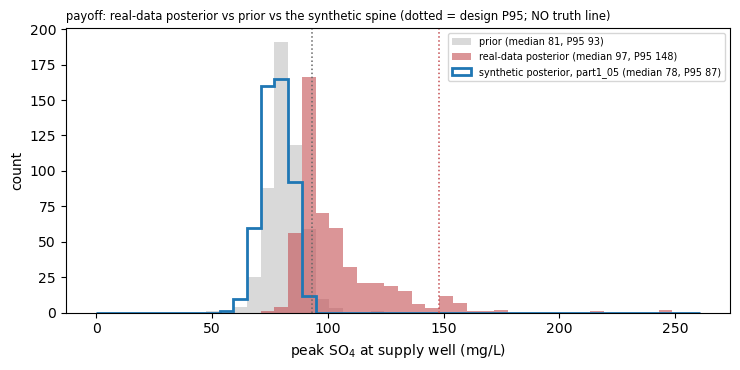

In [15]:
# load the part1_05 synthetic-spine posterior for the side-by-side (graceful skip)
p5_dtd = Path("..", "part1_05_dsi_basics", "dsi_template")
p5_post_fc = None
if (p5_dtd / "dsi.pst").exists():
    try:
        p5_pst = pyemu.Pst(str(p5_dtd / "dsi.pst"))
        p5_pst.try_parse_name_metadata()
        p5_obsen = p5_pst.ies.obsen
        p5_last = max(p5_obsen.index.get_level_values(0).unique())
        p5_post_fc = peak_so4_mgl(p5_obsen.loc[p5_last])
        print(f"loaded part1_05 synthetic-spine posterior: "
              f"median={p5_post_fc.median():.0f}, P95={p5_post_fc.quantile(0.95):.0f} mg/L")
    except Exception as e:
        print(f"part1_05 posterior present but not loadable ({e}); skipping the overlay")
else:
    print("part1_05 dsi_template not found; plotting the real-data prior/posterior only")

fig, ax = plt.subplots(figsize=(7.5, 3.8))
fc_max = max(prior_fc.max(), post_fc.max(),
             (p5_post_fc.max() if p5_post_fc is not None else 0))
bins = np.linspace(0, fc_max * 1.05, 45)
ax.hist(prior_fc, bins=bins, color="#D3D3D3", alpha=0.85,
        label=f"prior (median {prior_fc.median():.0f}, P95 {prior_fc.quantile(0.95):.0f})")
ax.hist(post_fc, bins=bins, color="#c44e52", alpha=0.6,
        label=f"real-data posterior (median {post_fc.median():.0f}, "
              f"P95 {post_fc.quantile(0.95):.0f})")
if p5_post_fc is not None:
    ax.hist(p5_post_fc, bins=bins, histtype="step", lw=2, color="#1f77b4",
            label=f"synthetic posterior, part1_05 (median {p5_post_fc.median():.0f}, "
                  f"P95 {p5_post_fc.quantile(0.95):.0f})")
ax.axvline(prior_fc.quantile(0.95), color="0.4", lw=1.1, ls=":")
ax.axvline(post_fc.quantile(0.95), color="#c44e52", lw=1.1, ls=":")
ax.set_xlabel("peak SO$_4$ at supply well (mg/L)")
ax.set_ylabel("count")
ax.set_title("payoff: real-data posterior vs prior vs the synthetic spine "
             "(dotted = design P95; NO truth line)", loc="left", fontsize="small")
ax.legend(fontsize="x-small")
fig.tight_layout()

## Where does the misfit concentrate?

A bad fit against real data is *ambiguous* - it could be the method, the model, or the weights. But the **pattern** of misfit is still informative: the species and sites that fit poorly *relative to their own noise* are where the model and the aquifer disagree most, and that disagreement is structural error showing itself. PESTPP-IES gives us two readouts. First, the **prior-data conflict** list it wrote when it drew the prior ensemble - observations the model cannot reach with any parameter draw:


In [16]:
pdc_path = dtd / "dsi.0.pdc.csv"
if pdc_path.exists() and pdc_path.stat().st_size > 0:
    pdc = pd.read_csv(pdc_path)
    if len(pdc):
        # the obsname carries obsid/variable tokens; pull them out for a readable summary
        pdc["obsid"] = pdc["name"].str.extract(r"obsid:([^_]+)")
        pdc["variable"] = pdc["name"].str.extract(r"variable:([a-z0-9]+)")
        print(f"{len(pdc)} observations in prior-data conflict "
              "(measured value the model cannot reach with any prior parameter draw)")
        print("\nby species:")
        print(pdc.groupby("variable").size().sort_values(ascending=False).to_string())
        print("\nby site:")
        print(pdc.groupby("obsid").size().sort_values(ascending=False).to_string())
    else:
        print("no prior-data conflict flagged")
else:
    print("no prior-data conflict file written")

14 observations in prior-data conflict (measured value the model cannot reach with any prior parameter draw)

by species:
variable
o0     8
no3    4
so4    2

by site:
obsid
wp3-f1    4
wp3-f5    3
wp1-f1    2
wp2-f1    2
wp3-f2    2
wp2-f3    1


Second, the **per-group phi** at the final iteration - mean misfit per site:species, in units of its own noise (each weighted residual is already divided by its sigma, so these are comparable across species). The groups at the top are the ones the conditioned model still cannot fit *even after* the smoother has done its best, relative to the error we allowed them. That ranking is the structural-error fingerprint:


final-iteration phi by site:species group (top 12 of 97 weighted groups):
wp3-f1:o0     101.260000
wp1-f1:o0      48.990900
wp2-f1:o0      40.373800
wp3-f2:no3     40.279926
wp3-f5:no3     40.077489
wp3-f5:so4     38.496726
wp3-f2:so4     27.177758
wp3-f3:no3     22.704289
wp3-f4:no3     21.289708
wp2-f3:no3     20.976309
wp2-f4:no3     16.012707
wp2-f3:o0      15.570035


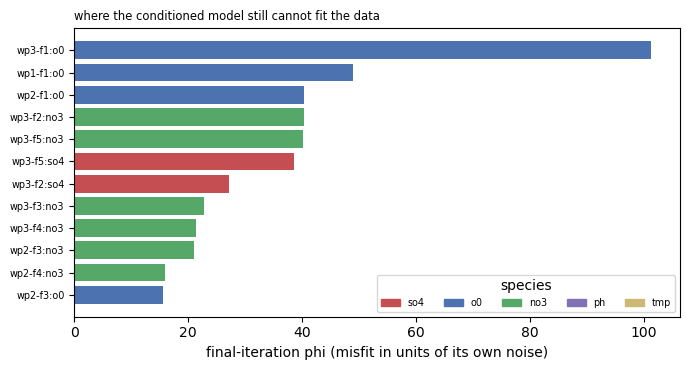

In [17]:
phigrp_path = dtd / "dsi.phi.group.csv"
phi_group = pd.read_csv(phigrp_path)
# one row per realisation per iteration; the group columns are everything but the
# bookkeeping columns. Take the final iteration and average the per-group phi
# across realisations.
meta_cols = ["iteration", "total_runs", "obs_realization", "par_realization"]
grp_cols = [c for c in phi_group.columns if c not in meta_cols]
final = phi_group.loc[phi_group["iteration"] == phi_group["iteration"].max()]
phi_by_group = final[grp_cols].astype(float).mean(axis=0).sort_values(ascending=False)
phi_by_group = phi_by_group[phi_by_group > 0]

print(f"final-iteration phi by site:species group (top 12 of "
      f"{len(phi_by_group)} weighted groups):")
print(phi_by_group.head(12).to_string())

top = phi_by_group.head(12)
fig, ax = plt.subplots(figsize=(7, 3.8))
species_of = lambda g: g.split(":")[-1]
palette = {"so4": "#c44e52", "o0": "#4c72b0", "no3": "#55a868",
           "ph": "#8172b3", "tmp": "#ccb974"}
colors = [palette.get(species_of(g), "0.5") for g in top.index]
ax.barh(range(len(top))[::-1], top.values, color=colors)
ax.set_yticks(range(len(top))[::-1])
ax.set_yticklabels(top.index, fontsize="x-small")
ax.set_xlabel("final-iteration phi (misfit in units of its own noise)")
ax.set_title("where the conditioned model still cannot fit the data",
             loc="left", fontsize="small")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
ax.legend(handles, palette.keys(), fontsize="x-small", title="species", ncol=5)
fig.tight_layout()

Read the two readouts together and the same story repeats: the misfit is not spread evenly, it piles up on particular species at particular sites. Those are the places the regular-grid, simplified-network model parts company with the real redox front - exactly the structural error the noise budget made no allowance for. With a *synthetic* truth this pattern could not appear: the truth came from the same model, so any group could in principle be driven to its noise floor. That it cannot here is the signature we came for.


A reminder worth keeping sharp: the fidelity check earlier told us the emulator is faithful to the *model* (it reproduces held-out model runs). It said nothing about whether the model is faithful to the *aquifer*. The misfit above is the second question, and no emulator diagnostic can answer it. Conflating the two - "the emulator passed, so the forecast is trustworthy" - is the most common way real-data analyses fool themselves.


## What the synthetic/real contrast taught

Running both ends of the series back to back is the point of the capstone. The contrast is the lesson:

- **The synthetic truth was a teaching instrument, not a crutch.** It let every method show its payoff against a known answer, so you could see *that the method works* before trusting it where the answer is hidden. That is the only honest order to learn in.
- **The mechanics are trivial; the epistemics are everything.** Swapping to real data took two columns and a noise file. What changed was not the code but what the numbers coming out of it are allowed to claim.
- **Misfit stops being evidence about parameters.** With a wrong model - and every model is wrong - low phi can mean good parameters or well-disguised structural error, and the data cannot tell you which. The noise model quietly becomes your structural-error budget, and you are choosing it, not measuring it. We deliberately left it at the synthetic budget, and the unfittable groups above are what that choice exposes.
- **A bad fit is ambiguous.** When the model cannot reach the data, you cannot tell from the numbers alone whether the culprit is the method, the model structure, or the weights. Coverage - "did we cover the truth?" - is simply unknowable where the forecast lives, because no truth was ever measured there.
- **The forecast lives where you have no data.** The supply well was never drilled. Decision support is, almost by definition, extrapolation to an unobserved place or time.
- **You still have to commit.** The decision date does not wait for certainty. The professional posture is humility: larger error allowances, scrutiny of the misfit pattern, and an explicit statement of the structural assumptions the forecast rests on - then carry the ambiguity honestly into the decision rather than hiding it behind a single number.


That last point is the whole reason the series chose emulation and uncertainty quantification over calibrate-then-forget. A single calibrated model hands the decision-maker a number and hides the ambiguity. The workflow you have now hands them a forecast distribution — median and P95 — a stated noise model, and an explicit structural caveat. It does not make the model right. It makes the modelling honest - and with reactive transport run costs of ~6 min per realisation, the emulator is what makes that honesty affordable. That is where real decision-support reactive transport modelling lives, and it is where the series ends.


### Where to go next

- Revisit [part1_07 dataworth](../part1_07_dataworth/dizon_dataworth.ipynb): with real data, the held-back cations question becomes "is it worth the field cost of sampling them?" - a real budget decision, not a thought experiment. Note that the field campaign only ever measured some cations (Ca, Na, Fe) and never others (Mg, K), which is itself a dataworth result the world handed you.
- Carry the structural-error framing into [part1_08 optimization](../part1_08_optimization/dizon_optimization.ipynb): a Pareto front read off a structurally-uncertain posterior needs its caveats stated on the figure, not buried in a footnote.
- For the deeper treatment of structural error and model adequacy, see the GMDSI publications linked from the [series README](../../README.md).
